# Explainable AI (SHAP + LIME) Notebook

This notebook contains a ready-to-run Explainable AI pipeline for your `super_ensemble` VotingClassifier. It includes global SHAP, local SHAP, LIME explanations, an aggregation method (Ensemble Explanation Aggregation), and a small real-time simulation example. 

**Assumptions:**
- You already have `super_ensemble` trained in the environment (voting='soft').
- `X_train`, `X_test`, and `y_test` (or `y_test`) are pandas DataFrames/Series present in the environment.

If you run the full notebook, it will save outputs to `xai_outputs/` and display inline plots where possible.

---

## 1. Install required packages (run once)

If you already installed the packages in your environment, you can skip this cell. Otherwise run the following cell.

 Run this cell if you need to install missing packages
 !pip install shap lime matplotlib scikit-learn pandas numpy

print('If packages were installed, restart the kernel and run the notebook cells again.')

## 2. Imports and helper functions

This cell imports the main libraries and defines helper functions. The functions are adapted from the module provided earlier and save outputs into `xai_outputs/`.

In [4]:
import numpy as np
import pandas as pd
import shap
from lime.lime_tabular import LimeTabularExplainer
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import json
import os
from IPython.display import Image, display
import joblib
import lightgbm as lgb

In [6]:
# importing super_ensemble 
super_ensemble = joblib.load("../notebooks/final_models/super_ensemble.pkl")

X_train = pd.read_csv("../data/train_test_data/X_train_smoteote.csv")
X_test = pd.read_csv("../data/train_test_data/X_test.csv")
y_train = pd.read_csv("../data/train_test_data/y_train_smoteote.csv")
y_test = pd.read_csv("../data/train_test_data/y_test.csv")

In [48]:
gender_map = {
    0.0: "female",
    1.0: "male"
}

industry_map = {
    0.0: "ecommerce",
    1.0: "subscription",
    2.0: "telecom"
}

payment_method_map = {
    0: "Bank transfer (Automatic)",
    1: "Cash on Delivery",
    2: "Credit Card",
    3: "Credit Card (Automatic)",
    4: "Debit Card",
    5: "Electronic Check",
    6: "Mailed Check",
    7: "Net Banking",
    8: "PayPal",
    9: "UPI"
}


In [57]:
plt.rcParams['figure.figsize'] = (9,6) #setting default size for all plots to get large and clear images

os.makedirs('xai_outputs', exist_ok=True) #folder to save outputa

# Helper: wrapper to get prob for class1 from model
# this function will help get the probability of only the churners class (class 1)
#pred_proba gives probability whether a customer will churn or not (gives both [[0.80,0.20],[0.30, 0.70]..]
#we only need the probability of churners as SHAP, LIME take only single column array
#this helps us always feed correct class probability, no confusion about the labels and consistent output across all XAI methods
def get_pred_proba_class1(model, X):
    probs = model.predict_proba(X)
    return probs[:, 1]

# compute SHAP explanations (global + local object)
"""
def predict_proba_class1(X):
    return super_ensemble.predict_proba(X)[:, 1]

def compute_shap_explanations(model, X_train, X_test, save_dir='xai_outputs'):
    import os
    os.makedirs(save_dir, exist_ok=True)

    # For Kernel SHAP, use a smaller background dataset for speed
    background = X_train.sample(100, random_state=42)

    # Build SHAP KernelExplainer (model-agnostic)
    explainer = shap.KernelExplainer(
        predict_proba_class1,          # top-level function (picklable)
        background.values,             # numpy array is safer
        feature_names=list(X_train.columns)
    )

    # Compute SHAP values for the test set (can limit to 50–100 rows for speed)
    shap_values = explainer(X_test.values)

    # --- SHAP PLOTS ---
    try:
        shap.summary_plot(shap_values, X_test, show=False)
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, 'shap_summary_beeswarm.png'), dpi=200)
        plt.close()
    except Exception as e:
        print("Warning: shap summary plot failed:", e)

    try:
        shap.plots.bar(shap_values, show=False)
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, 'shap_feature_importance_bar.png'), dpi=200)
        plt.close()
    except Exception as e:
        print("Warning: shap bar plot failed:", e)

    # Save SHAP explainer safely
    bundle = {
        "explainer": explainer,
        "background_columns": list(background.columns)
    }

    joblib.dump(bundle, "../backend/artifacts/shap_explainer.pkl")
    joblib.dump(list(X_train.columns), "../backend/artifacts/xai_feature_names.pkl")

    print("SHAP explainer + feature names saved successfully.")

    return explainer, shap_values
"""


def compute_shap_explanations(model, X_train, X_test, save_dir='xai_outputs'):
    os.makedirs(save_dir, exist_ok=True)
    # model-agnostic explainer using predict_proba for class1
    #function that will return probability of class 1
    def pred_proba_class1(X):
        return model.predict_proba(X)[:,1]
    #Building SHAP explainer
    explainer = shap.Explainer(pred_proba_class1, X_train, feature_names=list(X_train.columns))
    #calculating SHAP values for X_test
    shap_values = explainer(X_test)
    # Global plots
    try:
        shap.summary_plot(shap_values, X_test, show=False)
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, 'shap_summary_beeswarm.png'), dpi=200)
        plt.close()
    except Exception as e:
        print('Warning: shap summary plot failed:', e)
    try:
        shap.plots.bar(shap_values, show=False)
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, 'shap_feature_importance_bar.png'), dpi=200)
        plt.close()
    except Exception as e:
        print('Warning: shap bar plot failed:', e)
    return explainer, shap_values



# SHAP local for an index
def shap_local_for_index(explainer, shap_values, X_test, i, save_dir='xai_outputs'):
    os.makedirs(save_dir, exist_ok=True)
    val = shap_values[i]
    try:
        shap.plots.waterfall(val, show=False)
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, f'shap_waterfall_{i}.png'), dpi=200)
        plt.close()
    except Exception as e:
        print('Warning: shap waterfall failed:', e)
    per_feature_signed = pd.Series(val.values, index=X_test.columns)
    per_feature_abs = per_feature_signed.abs()
    return per_feature_signed, per_feature_abs

# LIME local explanation
def lime_local_for_index(model, X_train, X_test, i, class_names=['No Churn', 'Churn'], save_dir='xai_outputs', num_features=10):
    os.makedirs(save_dir, exist_ok=True)
    lime_explainer = LimeTabularExplainer(
        training_data=np.array(X_train),
        feature_names=list(X_train.columns),
        class_names=class_names,
        mode='classification',
        discretize_continuous=True,
        random_state=42
    )
    instance = X_test.iloc[i].values
    exp = lime_explainer.explain_instance(instance, model.predict_proba, num_features=num_features)
    lm_list = exp.as_list(label=1)
    lime_weights = pd.Series({feat: weight for feat, weight in lm_list})
    for f in X_train.columns:
        if f not in lime_weights.index:
            lime_weights.loc[f] = 0.0
    lime_weights = lime_weights.loc[X_train.columns]
    with open(os.path.join(save_dir, f'lime_explanation_{i}.txt'), 'w') as fh:
        fh.write('LIME explanation for index {}\n\n'.format(i))
        for feat, weight in lm_list:
            fh.write(f"{feat} : {weight}\n")
    return lime_weights, dict(lm_list)

# Aggregate
def aggregate_explanations(shap_abs_series, lime_series, shap_weight=0.6, lime_weight=0.4):
    df = pd.DataFrame({'shap_raw': shap_abs_series, 'lime_raw': lime_series.abs()}).fillna(0.0)
    scaler = MinMaxScaler()
    df[['shap_norm', 'lime_norm']] = scaler.fit_transform(df[['shap_raw', 'lime_raw']])
    df['final_score'] = shap_weight * df['shap_norm'] + lime_weight * df['lime_norm']
    df = df.sort_values('final_score', ascending=False)
    return df

# end-to-end explain one instance
def explain_instance(model, explainer, shap_values, X_train, X_test, i, shap_weight=0.6, lime_weight=0.4, save_dir='xai_outputs'):
    os.makedirs(save_dir, exist_ok=True)
    shap_signed, shap_abs = shap_local_for_index(explainer, shap_values, X_test, i, save_dir=save_dir)
    lime_weights, lime_list = lime_local_for_index(model, X_train, X_test, i, save_dir=save_dir)
    agg = aggregate_explanations(shap_abs, lime_weights, shap_weight=shap_weight, lime_weight=lime_weight)
    topk = agg.head(10)
    with open(os.path.join(save_dir, f'aggregated_explanation_{i}.json'), 'w') as fh:
        json.dump(topk['final_score'].to_dict(), fh, indent=2)
    return {'shap_signed': shap_signed, 'shap_abs': shap_abs, 'lime_weights': lime_weights, 'aggregate_df': agg}

# NATURAL LANGUAGE EXPLANATION
def interpret_age(value):
    if value < -0.5:
        return "a young customer"
    elif value < 0.5:
        return "a middle-aged customer"
    else:
        return "a senior customer"

def interpret_tenure(value):
    if value < -0.5:
        return "a new customer with short tenure"
    elif value < 0.5:
        return "a medium-tenure customer"
    else:
        return "a long-term customer"

def interpret_monthly_charges(value):
    if value < -0.3:
        return "low monthly charges"
    elif value < 0.3:
        return "moderate monthly charges"
    else:
        return "high monthly charges"



def explain_in_sentence_natural(model, explainer, shap_values, 
                                X_train, X_test, index):

    # ----- FIXED FEATURE NAMES -----
    feature_names = [
        "gender",           # 0
        "age",              # 1
        "tenure",           # 2
        "monthly charges",  # 3
        "payment method"    # 4
    ]

    industry_col = 5  # fixed

    # ===== INDUSTRY DECODING =====
    try:
        industry_code = X_test.iloc[index].iloc[industry_col]
        industry_name = industry_map.get(industry_code, "unknown")
    except:
        industry_name = "unknown"

    # ===== PREDICT PROBABILITY =====
    prob = float(model.predict_proba(X_test.iloc[[index]])[0,1])

    # Dynamic churn risk text based on probability
    if prob < 0.5:
        churn_risk_text = "which is associated with lower churn risk"
    else:
        churn_risk_text = "which is associated with higher churn risk"

    # ===== SHAP + LIME RESULT =====
    result = explain_instance(model, explainer, shap_values, X_train, X_test, index)

    agg = result['aggregate_df']
    agg = agg[~agg.index.astype(str).str.contains("tda", case=False)]
    top_feats = agg.head(5).index.tolist()

    explanations = []

    # ===== NATURAL LANGUAGE FOR EACH TOP FEATURE =====
    for feat in top_feats:

        # numeric index → actual feature
        if str(feat).isdigit():
            col = int(feat)
            if col > 4:
                continue
            name = feature_names[col]
        else:
            name = feat.lower()

        # Get raw value
        raw_value = X_test.iloc[index].iloc[col]

        # ----- Natural conversion -----
        if name == "gender":
            explanations.append(f"is {gender_map.get(raw_value, 'unknown gender')}")

        elif name == "age":
            explanations.append(f"is {interpret_age(raw_value)}")

        elif name == "tenure":
            explanations.append(f"is {interpret_tenure(raw_value)}")

        elif name == "monthly charges":
            explanations.append(f"has {interpret_monthly_charges(raw_value)}")

        elif name == "payment method":
            decoded = payment_method_map.get(int(raw_value), "unknown payment method")
            explanations.append(f"uses {decoded}, {churn_risk_text}")

        else:
            explanations.append(name.replace("_"," "))

    # Combine reasons
    if len(explanations) > 1:
        reasons = ", ".join(explanations[:-1]) + ", and " + explanations[-1]
    else:
        reasons = explanations[0]

    # ===== FINAL NATURAL SENTENCE =====
    sentence = (
        f"Customer {index} from the {industry_name} industry is predicted to churn "
        f"with a probability of {prob:.2f}. "
        f"This is mainly because the customer {reasons}."
    )

    return sentence


# real-time stream simulation
def realtime_simulation_stream(model, explainer, shap_values, X_train, X_test, stream_indices, save_dir='xai_outputs'):
    os.makedirs(save_dir, exist_ok=True)
    results = []
    for i in stream_indices:
        x_row = X_test.iloc[[i]]
        pred_proba = model.predict_proba(x_row)[0,1]
        explanation = explain_instance(model, explainer, shap_values, X_train, X_test, i, save_dir=save_dir)
        top_features = explanation['aggregate_df'].head(5).index.tolist()
        results.append({'index': i, 'pred_proba': float(pred_proba), 'top_features': top_features, 'top_scores': explanation['aggregate_df'].head(5)['final_score'].round(4).tolist()})
        print(f"[stream] idx={i} prob={pred_proba:.4f} top_features={top_features}")
    return pd.DataFrame(results)

print('Helpers loaded. Ready for XAI steps.')

Helpers loaded. Ready for XAI steps.


## 3. Quick checks

Run these checks to ensure `super_ensemble` and data variables exist and `predict_proba` works. If any check fails, load or re-fit your model and data before continuing.

In [54]:
# Quick checks - run these cells after loading your model and data

try:
    print('super_ensemble type:', type(super_ensemble))
except Exception as e:
    print('super_ensemble not found in environment. Make sure you have the variable defined. Error:', e)

try:
    print('X_train shape:', X_train.shape)
    print('X_test shape :', X_test.shape)
except Exception as e:
    print('X_train / X_test not found. Error:', e)

# predict_proba test (run only if model exists)
try:
    probs = super_ensemble.predict_proba(X_test[:5])
    print('predict_proba sample shape:', probs.shape)
    print('sample probs:', probs)
except Exception as e:
    print('predict_proba failed. Error:', e)


super_ensemble type: <class 'sklearn.ensemble._voting.VotingClassifier'>
X_train shape: (20108, 350)
X_test shape : (4226, 350)
predict_proba sample shape: (5, 2)
sample probs: [[0.3813644  0.6186356 ]
 [0.42725522 0.57274478]
 [0.77815368 0.22184631]
 [0.66754585 0.33245414]
 [0.60207169 0.39792832]]


## 4. Compute SHAP explainer (global + local object)

This cell computes the SHAP explainer and saves global plots into `xai_outputs/`. This might take a bit of time depending on dataset size.

In [55]:
# Compute SHAP explainer
explainer, shap_values = compute_shap_explanations(super_ensemble, X_train, X_test, save_dir='xai_outputs')

# Display saved global plots if available
if os.path.exists('xai_outputs/shap_feature_importance_bar.png'):
    display(Image(filename='xai_outputs/shap_feature_importance_bar.png'))
if os.path.exists('xai_outputs/shap_summary_beeswarm.png'):
    display(Image(filename='xai_outputs/shap_summary_beeswarm.png'))


/Users/krishbharatkhatri/Documents/coding/customer-churn-prediction/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  0%|          | 0/4226 [00:00<?, ?it/s]

/Users/krishbharatkhatri/Documents/coding/customer-churn-prediction/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/krishbharatkhatri/Documents/coding/customer-churn-prediction/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/krishbharatkhatri/Documents/coding/customer-churn-prediction/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/krishbharatkhatri/Documents/coding/customer-churn-prediction/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  war

KeyboardInterrupt: 

## 5. Explain a single instance (local SHAP + LIME + Aggregation)

Choose an index `i` from `X_test`. The cell will create SHAP waterfall, LIME text file, and an aggregated JSON with top features.

/Users/krishbharatkhatri/Documents/coding/customer-churn-prediction/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Top aggregated features (final_score):
              shap_raw  lime_raw  shap_norm  lime_norm  final_score
5             0.327088       0.0   1.000000        0.0     0.600000
2             0.060747       0.0   0.185720        0.0     0.111432
3             0.037570       0.0   0.114862        0.0     0.068917
4             0.029040       0.0   0.088784        0.0     0.053270
1             0.024160       0.0   0.073864        0.0     0.044319
tda_node_11   0.011060       0.0   0.033813        0.0     0.020288
0             0.002081       0.0   0.006362        0.0     0.003817
tda_node_324  0.001823       0.0   0.005572        0.0     0.003343
tda_node_165  0.001332       0.0   0.004073        0.0     0.002444
tda_node_80   0.000977       0.0   0.002986        0.0     0.001792


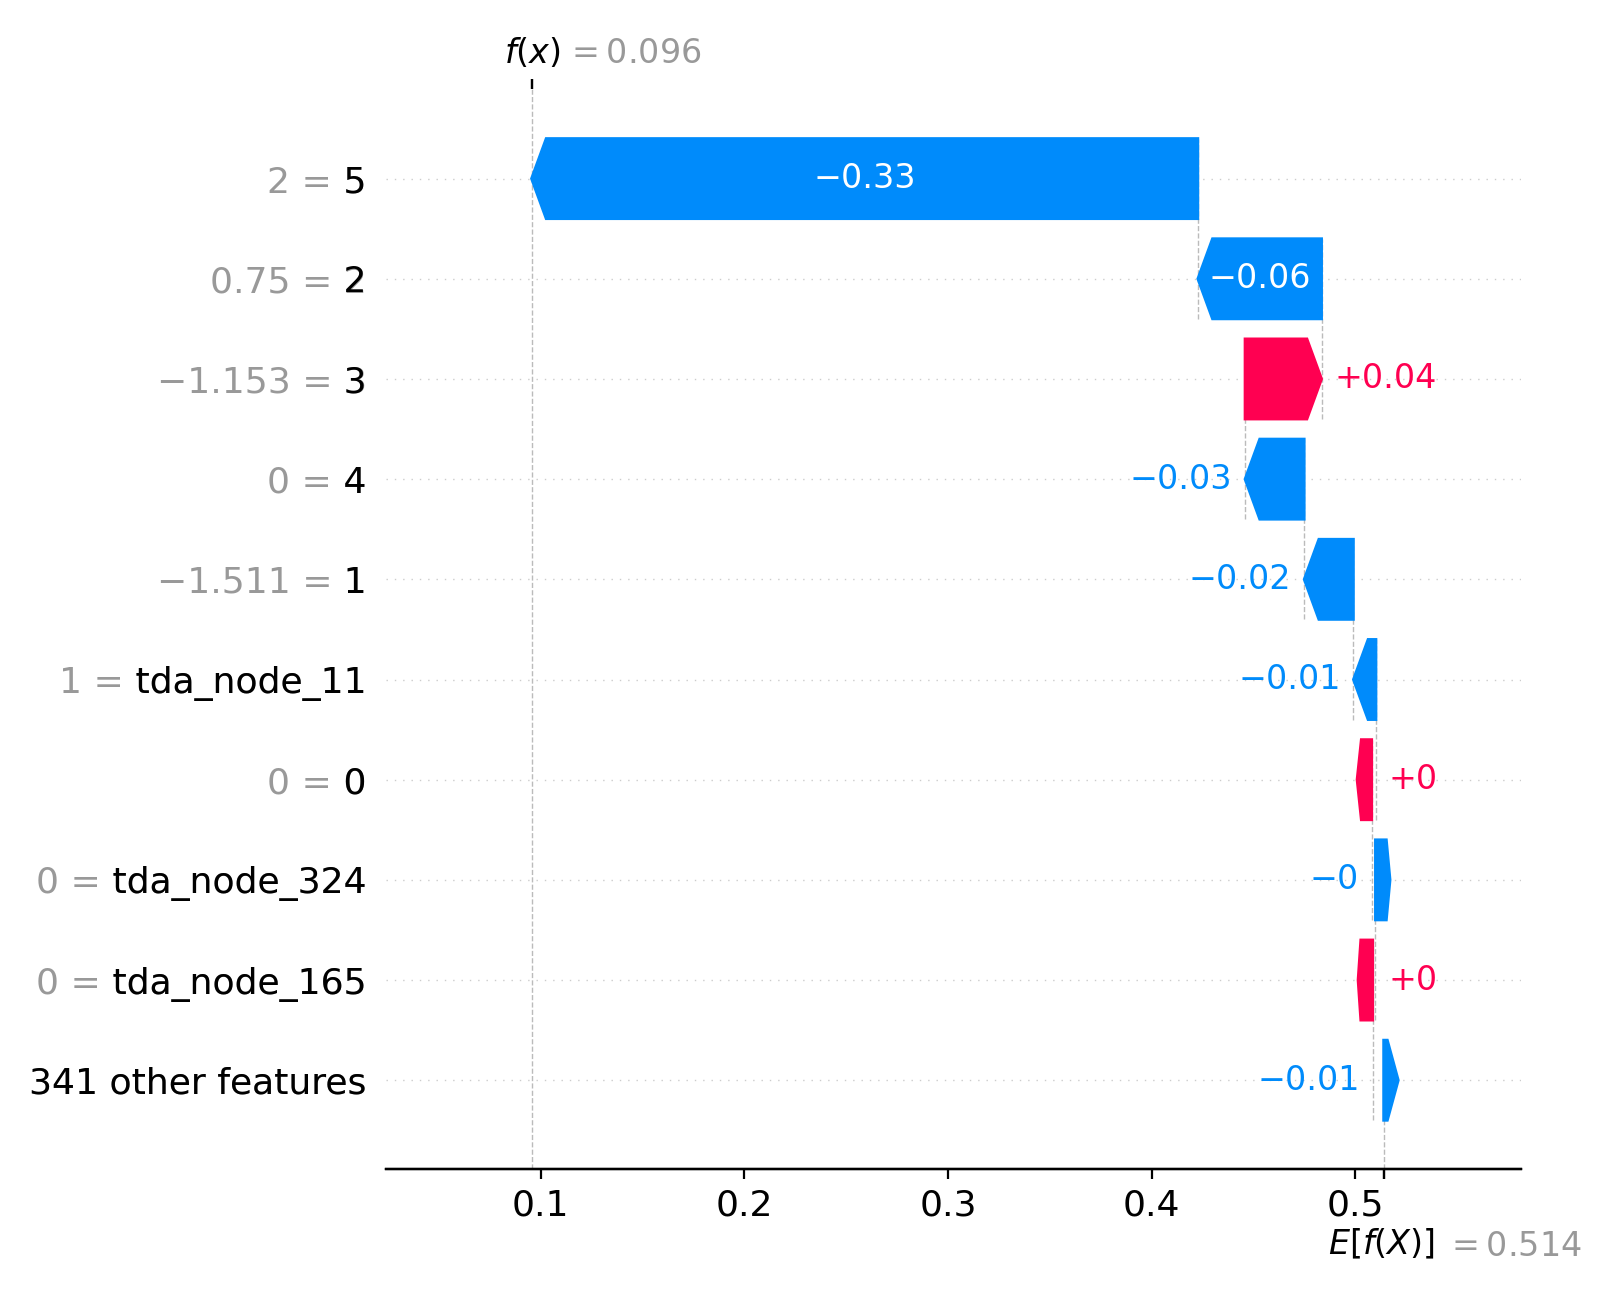


LIME text file (first 20 lines):
LIME explanation for index 10

1.00 < 5 <= 2.00 : -0.25844089781521506
tda_node_16 <= 0.00 : -0.14263042542629872
tda_node_118 <= 0.00 : -0.1350880858334968
tda_node_99 <= 0.00 : -0.112174612986668
tda_node_324 <= 0.00 : -0.11193199483912258
tda_node_120 <= 0.00 : 0.10023810996660833
tda_node_145 <= 0.00 : -0.0838185397450802
tda_node_94 <= 0.00 : 0.06015468974201768
tda_node_113 <= 0.00 : 0.04274406881225076
tda_node_41 <= 0.00 : -0.028185046113099372

Aggregated JSON top features:
{
  "5": 0.5999999999999999,
  "2": 0.11143194469906861,
  "3": 0.06891693377006987,
  "4": 0.053270149715696984,
  "1": 0.04431850324964962,
  "tda_node_11": 0.02028756366422658,
  "0": 0.003817028860824383,
  "tda_node_324": 0.0033432167090148373,
  "tda_node_165": 0.002444006496258398,
  "tda_node_80": 0.0017915029367209798
}


In [13]:
# Explain instance - change index i as desired
i = 10
res = explain_instance(super_ensemble, explainer, shap_values, X_train, X_test, i=i, shap_weight=0.6, lime_weight=0.4, save_dir='xai_outputs')

print('\nTop aggregated features (final_score):')
print(res['aggregate_df'].head(10))

# show saved images/texts if present
wf = f'xai_outputs/shap_waterfall_{i}.png'
if os.path.exists(wf):
    display(Image(filename=wf))
lt = f'xai_outputs/lime_explanation_{i}.txt'
if os.path.exists(lt):
    print('\nLIME text file (first 20 lines):')
    with open(lt, 'r') as fh:
        for j, line in enumerate(fh):
            if j>=20: break
            print(line.strip())

aggf = f'xai_outputs/aggregated_explanation_{i}.json'
if os.path.exists(aggf):
    print('\nAggregated JSON top features:')
    with open(aggf, 'r') as fh:
        print(fh.read())


## 6. Run a small real-time simulation (streamed rows)

This will simulate streaming a few rows from `X_test` and will print the churn probability and top aggregated features for each streamed customer.

In [14]:
# Simulate streaming - provide indices present in X_test
stream_indices = [10, 20, 30]
stream_df = realtime_simulation_stream(super_ensemble, explainer, shap_values, X_train, X_test, stream_indices, save_dir='xai_outputs')

print('\nStream summary:')
print(stream_df)


/Users/krishbharatkhatri/Documents/coding/customer-churn-prediction/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[stream] idx=10 prob=0.0956 top_features=['5', '2', '3', '4', '1']


/Users/krishbharatkhatri/Documents/coding/customer-churn-prediction/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[stream] idx=20 prob=0.1729 top_features=['5', '2', '3', '4', 'tda_node_25']


/Users/krishbharatkhatri/Documents/coding/customer-churn-prediction/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[stream] idx=30 prob=0.4875 top_features=['5', '3', '1', '2', '4']

Stream summary:
   index  pred_proba               top_features  \
0     10    0.095564            [5, 2, 3, 4, 1]   
1     20    0.172947  [5, 2, 3, 4, tda_node_25]   
2     30    0.487540            [5, 3, 1, 2, 4]   

                              top_scores  
0  [0.6, 0.1114, 0.0689, 0.0533, 0.0443]  
1  [0.6, 0.2702, 0.1868, 0.0657, 0.0607]  
2  [0.6, 0.3021, 0.2103, 0.1708, 0.0582]  


In [58]:

explainer, shap_values = compute_shap_explanations(super_ensemble, X_train, X_test)


PermutationExplainer explainer: 4227it [04:43, 14.39it/s]                                                            
/var/folders/vz/dx6hxp0d2dggzmjsyf6_pzv00000gn/T/ipykernel_77457/1044711842.py:80: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=False)


In [59]:
sentence = explain_in_sentence_natural(super_ensemble, explainer, shap_values, X_train, X_test, index=25)
print(sentence)

/Users/krishbharatkhatri/Documents/coding/customer-churn-prediction/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Customer 25 from the subscription industry is predicted to churn with a probability of 0.23. This is mainly because the customer has moderate monthly charges, is a senior customer, uses Debit Card, which is associated with lower churn risk, and is a long-term customer.


In [46]:
sentence = explain_in_sentence_natural(super_ensemble, explainer, shap_values, X_train, X_test, index=449)
print(sentence)

/Users/krishbharatkhatri/Documents/coding/customer-churn-prediction/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Customer 449 from the ecommerce industry is predicted to churn with a probability of 0.60. This is mainly because the customer has high monthly charges, is a young customer, is a medium-tenure customer, and uses Electronic Check, which is associated with higher churn risk.


In [60]:
# SAVE EXPLAINER + BACKGROUND DATA
joblib.dump({
    "explainer": explainer,
    "background": X_train  # or X_train.sample(100)
}, "shap_explainer.pkl")

#joblib.dump(list(X_train.columns), "../models/xai_feature_names.pkl")

print("Saved SHAP + feature names")

PicklingError: Can't pickle <function compute_shap_explanations.<locals>.pred_proba_class1 at 0x310156340>: it's not found as __main__.compute_shap_explanations.<locals>.pred_proba_class1

## 7. Notes & Next steps

- You can change `shap_weight` and `lime_weight` in the `explain_instance` call to justify your aggregation strategy.
- For more robust LIME results, repeat LIME multiple times and average the weights.
- If your features are scaled and you want human-readable explanations, consider inverse-transforming numeric features before showing them.
- Use `xai_outputs/` images and text files directly in your final report.